In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/hoangtung719/drowsiness-dataset/Dataset/Val/Open_Eyes/s0001_02878_0_1_1_0_1_01.png
/kaggle/input/datasets/hoangtung719/drowsiness-dataset/Dataset/Val/Open_Eyes/_163.jpg
/kaggle/input/datasets/hoangtung719/drowsiness-dataset/Dataset/Val/Open_Eyes/_19.jpg
/kaggle/input/datasets/hoangtung719/drowsiness-dataset/Dataset/Val/Open_Eyes/s0001_03002_0_1_1_2_0_01.png
/kaggle/input/datasets/hoangtung719/drowsiness-dataset/Dataset/Val/Open_Eyes/_9.jpg
/kaggle/input/datasets/hoangtung719/drowsiness-dataset/Dataset/Val/Open_Eyes/s0001_02889_0_1_1_0_0_01.png
/kaggle/input/datasets/hoangtung719/drowsiness-dataset/Dataset/Val/Open_Eyes/s0001_02377_0_0_1_0_0_01.png
/kaggle/input/datasets/hoangtung719/drowsiness-dataset/Dataset/Val/Open_Eyes/s0001_03019_0_1_1_2_0_01.png
/kaggle/input/datasets/hoangtung719/drowsiness-dataset/Dataset/Val/Open_Eyes/_167.jpg
/kaggle/input/datasets/hoangtung719/drowsiness-dataset/Dataset/Val/Open_Eyes/s0001_02394_0_0_1_0_0_01.png
/kaggle/input/datasets/

In [4]:
import tensorflow as tf
tf.debugging.set_log_device_placement(False)


In [5]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten,Conv2D,MaxPooling2D , Flatten,BatchNormalization,Dropout
import matplotlib.pyplot as plt
import cv2

In [6]:
import os

def make_subset(src_base, split, classes, dst_base):
    for cls in classes:
        src = os.path.join(src_base, split, cls)
        dst = os.path.join(dst_base, split, cls)
        os.makedirs(dst, exist_ok=True)
        for f in os.listdir(src):
            os.symlink(os.path.join(src, f), os.path.join(dst, f))

base = '/kaggle/input/datasets/hoangtung719/drowsiness-dataset/Dataset'

# Eye-only dataset (ignores Yawn/No_yawn entirely)
for split in ['Train', 'Val', 'Test']:
    make_subset(base, split, ['Open_Eyes', 'Closed_Eyes'], '/kaggle/working/eye_data')

# Yawn-only dataset (ignores Open_Eyes/Closed_Eyes entirely)
for split in ['Train', 'Val', 'Test']:
    make_subset(base, split, ['Yawn', 'No_yawn'], '/kaggle/working/yawn_data')

In [7]:
IMG_SIZE = (128,128)

In [8]:
train_ds_eye = keras.utils.image_dataset_from_directory(
    directory='/kaggle/working/eye_data/Train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=IMG_SIZE
)
train_ds_yawn = keras.utils.image_dataset_from_directory(
    directory='/kaggle/working/yawn_data/Train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=IMG_SIZE
)
validation_ds_eye = keras.utils.image_dataset_from_directory(
    directory='/kaggle/working/eye_data/Val',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=IMG_SIZE
)
validation_ds_yawn = keras.utils.image_dataset_from_directory(
    directory='/kaggle/working/yawn_data/Val',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=IMG_SIZE
)
test_ds_eye = keras.utils.image_dataset_from_directory(
    directory='/kaggle/working/eye_data/Test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size = IMG_SIZE
)
test_ds_yawn = keras.utils.image_dataset_from_directory(
    directory='/kaggle/working/yawn_data/Test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size = IMG_SIZE
)

Found 4233 files belonging to 2 classes.
Found 4315 files belonging to 2 classes.
Found 672 files belonging to 2 classes.
Found 882 files belonging to 2 classes.
Found 547 files belonging to 2 classes.
Found 917 files belonging to 2 classes.


In [9]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
])

In [10]:
def get_callbacks(name):
    return [
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint(f'{name}_best.h5', save_best_only=True, monitor='val_accuracy')
    ]

In [11]:
base_model = tf.keras.applications.MobileNetV3Large(
    input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet'
)
base_model.trainable = False   # freeze entirely

model_eye = tf.keras.Sequential([
    base_model,   # no Rescaling layer before this — MobileNetV3 handles it internally
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_eye.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_fe_eye = model_eye.fit(
    train_ds_eye, validation_data=validation_ds_eye,
    epochs=15, callbacks=get_callbacks('eye_fe_v3')
)

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:519: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15


2026-07-19 10:13:05.136020: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-19 10:13:05.271110: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-19 10:13:05.605054: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-19 10:13:05.742689: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1784455989.406198     137 device_compiler.h:196]

132/133 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8870 - loss: 0.2458

2026-07-19 10:13:24.399417: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-19 10:13:24.532490: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-19 10:13:24.843060: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-19 10:13:24.979934: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-19 10:13:25.115785: E external/local_xla/xla/stream_

133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.8876 - loss: 0.2447

133/133 ━━━━━━━━━━━━━━━━━━━━ 48s 201ms/step - accuracy: 0.9591 - loss: 0.1045 - val_accuracy: 0.9732 - val_loss: 0.0971
Epoch 2/15
132/133 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9971 - loss: 0.0125

133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9972 - loss: 0.0117 - val_accuracy: 0.9792 - val_loss: 0.0935
Epoch 3/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9974 - loss: 0.0069 - val_accuracy: 0.9762 - val_loss: 0.1274
Epoch 4/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9981 - loss: 0.0072 - val_accuracy: 0.9777 - val_loss: 0.1232
Epoch 5/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9993 - loss: 0.0025 - val_accuracy: 0.9762 - val_loss: 0.1449
Epoch 6/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 1.0000 - loss: 6.9819e-04 - val_accuracy: 0.9792 - val_loss: 0.1171
Epoch 7/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 1.0000 - loss: 1.8949e-04 - val_accuracy: 0.9792 - val_loss: 0.1232


In [12]:
test_loss, test_acc = model_eye.evaluate(test_ds_eye)
print(f"Eye model — Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.4f}")

17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9949 - loss: 0.0211

2026-07-19 10:13:58.378646: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-19 10:13:58.512234: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-19 10:13:58.815538: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-19 10:13:58.953470: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-19 10:13:59.090456: E external/local_xla/xla/stream_

18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 658ms/step - accuracy: 0.9927 - loss: 0.0238
Eye model — Test loss: 0.0238, Test accuracy: 0.9927


In [13]:
base_model = tf.keras.applications.MobileNetV3Large(
    input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet'
)
base_model.trainable = False

model_yawn = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_yawn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_fe_yawn = model_yawn.fit(         
    train_ds_yawn, validation_data=validation_ds_yawn,
    epochs=15, callbacks=get_callbacks('yawn_fe_v3')
)

Epoch 1/15
133/135 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8558 - loss: 0.3241

2026-07-19 10:14:29.703978: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-19 10:14:29.839969: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-19 10:14:30.161150: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-19 10:14:30.298597: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.8569 - loss: 0.3223

2026-07-19 10:14:48.104962: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-19 10:14:48.239290: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-19 10:14:48.556003: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-19 10:14:48.693021: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


135/135 ━━━━━━━━━━━━━━━━━━━━ 50s 276ms/step - accuracy: 0.9249 - loss: 0.2000 - val_accuracy: 0.9649 - val_loss: 0.0815
Epoch 2/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9665 - loss: 0.0994

135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9745 - loss: 0.0783 - val_accuracy: 0.9819 - val_loss: 0.0913
Epoch 3/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9810 - loss: 0.0662 - val_accuracy: 0.9739 - val_loss: 0.1077
Epoch 4/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9875 - loss: 0.0440 - val_accuracy: 0.9739 - val_loss: 0.1068
Epoch 5/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9900 - loss: 0.0326 - val_accuracy: 0.9739 - val_loss: 0.1081
Epoch 6/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9926 - loss: 0.0248 - val_accuracy: 0.9739 - val_loss: 0.1195


In [14]:
test_loss, test_acc = model_yawn.evaluate(test_ds_yawn)
print(f"Yawn model — Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.4f}")

27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9566 - loss: 0.1173

2026-07-19 10:15:10.740821: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-19 10:15:10.873712: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-19 10:15:11.192946: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-19 10:15:11.329606: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-19 10:15:11.466260: E external/local_xla/xla/stream_

29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 438ms/step - accuracy: 0.9618 - loss: 0.1028
Yawn model — Test loss: 0.1028, Test accuracy: 0.9618


In [18]:
import ipywidgets as widgets
from IPython.display import display

uploader = widgets.FileUpload(
    accept='image/*',
    multiple=False
)

display(uploader)

FileUpload(value=(), accept='image/*', description='Upload')

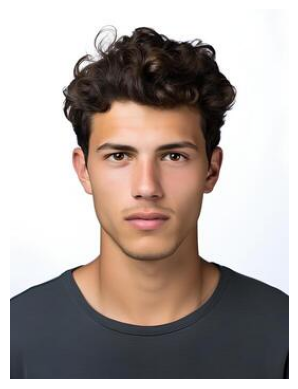

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Prediction: Closed_Eyes (confidence: 0.0000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Prediction: Yawn (confidence: 0.9388)


In [29]:
import io
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt

# Get uploaded image
uploaded_file = list(uploader.value)[0]
image_bytes = uploaded_file['content']

# Open image
img = Image.open(io.BytesIO(image_bytes)).convert('RGB')

# Display
plt.imshow(img)
plt.axis('off')
plt.show()

# Resize according to your model input size
img = img.resize((128, 128))

# Convert to array
img_array = np.array(img, dtype=np.float32)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model_eye.predict(img_array)
prob = pred[0][0]
label = train_ds_eye.class_names[int(prob > 0.5)]
print(f"Prediction: {label} (confidence: {prob:.4f})")
pred1 = model_yawn.predict(img_array)
prob = pred1[0][0]
label1 = train_ds_yawn.class_names[int(prob > 0.5)]
print(f"Prediction: {label1} (confidence: {prob:.4f})")

In [15]:
model_eye.save('/kaggle/working/eye_model_final.keras')
model_yawn.save('/kaggle/working/yawn_model_final.keras')